# 04 - Augmentation and dataset pipeline

Builds the transform pipelines and the Dataset class used for training. No model or training here, just checking the pipeline end to end before the next notebook.

Assumes this notebook is run from the project root, same as the previous notebooks.

In [1]:
import json
from pathlib import Path
from collections import Counter

import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

print(torch.__version__, torchvision.__version__)


2.14.0+cu130 0.29.0+cu130


In [2]:
assert Path("normalization_stats.json").exists(), "run this notebook from the project root"
assert Path("processed/224/train").exists(), "expected processed/224 folder not found"


## Shared module

citrus_common.py holds the transforms and Dataset class so the training notebook can reuse them instead of copy-pasting. Written to disk here, then imported below to check it actually works.

In [3]:
%%writefile citrus_common.py
"""
Shared transforms and dataset class for the citrus leaf project.
Used by the augmentation notebook and later by the training notebook.
"""

import json
from pathlib import Path

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


def load_normalization_stats(path="normalization_stats.json"):
    """Read the per-channel mean/std saved during preprocessing.

    Returns (mean, std), each a tuple of 3 floats in RGB order.
    """
    with open(path, "r") as f:
        stats = json.load(f)
    mean = tuple(stats["mean"])
    std = tuple(stats["std"])
    return mean, std


class AddGaussianNoise:
    """Adds Gaussian noise to a tensor image, then clamps back to [0, 1].

    Meant to go after ToTensor() and before Normalize() in the pipeline,
    since it assumes pixel values are still in [0, 1].
    """

    def __init__(self, std_dev=0.02):
        self.std_dev = std_dev

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std_dev
        return torch.clamp(tensor + noise, 0.0, 1.0)

    def __repr__(self):
        return f"{self.__class__.__name__}(std_dev={self.std_dev})"


def get_transforms(augment: bool, mean, std, size: int = 224):
    """Build the transform pipeline for training or for val/test.

    size is the target resolution and is exposed as a parameter so the
    same function works for both the 224 and 128 processed variants.
    """
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.RandomResizedCrop(size, scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            AddGaussianNoise(std_dev=0.02),
            transforms.Normalize(mean, std),
        ])
    else:
        # no random ops here - just make sure size matches and normalize
        return transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


class CitrusLeafDataset(Dataset):
    """Loads images from root_dir/split/<class_label>/*.jpg.

    class_to_idx is built from the sorted class folder names, so it
    comes out the same regardless of which split is loaded first -
    train/val/test are scanned independently but must agree.
    """

    def __init__(self, root_dir, split, transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform

        split_dir = self.root_dir / split
        class_names = sorted(d.name for d in split_dir.iterdir() if d.is_dir())
        self.class_to_idx = {name: idx for idx, name in enumerate(class_names)}

        self.samples = []
        for class_name in class_names:
            label = self.class_to_idx[class_name]
            for img_path in sorted((split_dir / class_name).glob("*.jpg")):
                self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


Overwriting citrus_common.py


In [4]:
import importlib
import citrus_common
importlib.reload(citrus_common)

from citrus_common import (
    load_normalization_stats,
    AddGaussianNoise,
    get_transforms,
    CitrusLeafDataset,
)

print("citrus_common imported OK")


citrus_common imported OK


## Transforms

Training transform includes flip, rotation, resized crop, color jitter, and a bit of Gaussian noise, all before normalizing with the dataset's own mean/std (not ImageNet stats). Val/test transform just resizes and normalizes, nothing random.

In [5]:
mean, std = load_normalization_stats("normalization_stats.json")
print("mean:", mean)
print("std:", std)

train_transform_224 = get_transforms(augment=True, mean=mean, std=std, size=224)
eval_transform_224 = get_transforms(augment=False, mean=mean, std=std, size=224)


mean: (0.5257163855539984, 0.5160105040026677, 0.34659739807732487)
std: (0.21506874681810037, 0.20516077417601286, 0.22465844151318715)


## Datasets

Train/val/test are scanned separately, so class_to_idx has to come out identical across all three or label indices would not line up between splits. Checking that here rather than assuming it.

In [6]:
train_dataset = CitrusLeafDataset("processed/224", "train", transform=train_transform_224)
val_dataset = CitrusLeafDataset("processed/224", "val", transform=eval_transform_224)
test_dataset = CitrusLeafDataset("processed/224", "test", transform=eval_transform_224)

print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))

print("train class_to_idx:", train_dataset.class_to_idx)
print("val class_to_idx:", val_dataset.class_to_idx)
print("test class_to_idx:", test_dataset.class_to_idx)

same_mapping = (train_dataset.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx)
print("class_to_idx consistent across splits:", "PASS" if same_mapping else "FAIL")
assert same_mapping, "class_to_idx mapping differs between splits"


train: 1131
val: 242
test: 240
train class_to_idx: {'aphids': 0, 'gummosis': 1, 'healthy': 2, 'leaf_minnor': 3}
val class_to_idx: {'aphids': 0, 'gummosis': 1, 'healthy': 2, 'leaf_minnor': 3}
test class_to_idx: {'aphids': 0, 'gummosis': 1, 'healthy': 2, 'leaf_minnor': 3}
class_to_idx consistent across splits: PASS


## What augmentation actually looks like

Same source image run through the training transform 6 times. Flip, rotation, crop, and color jitter should all come out different since they're random per call.

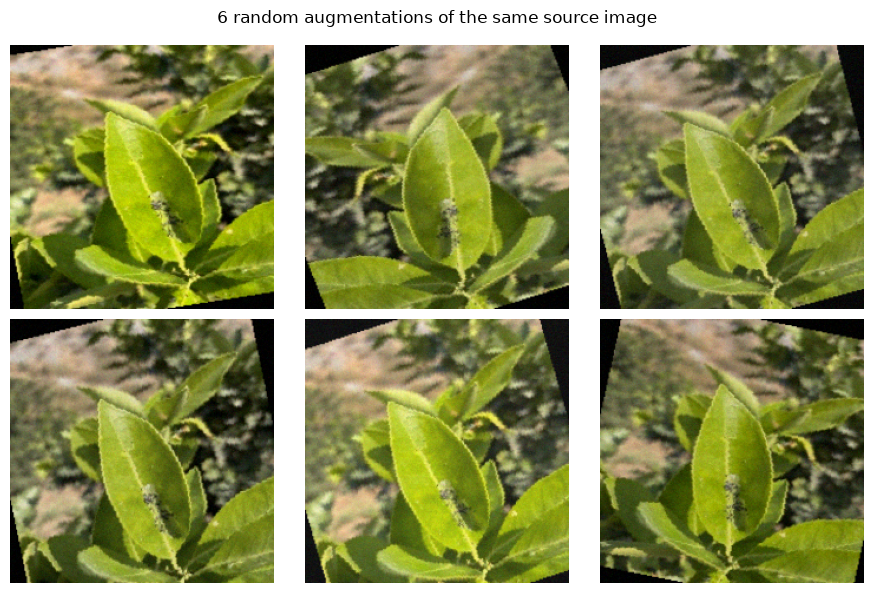

In [7]:
sample_path, sample_label = train_dataset.samples[0]
sample_image = Image.open(sample_path).convert("RGB")

mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax in axes.flat:
    aug = train_transform_224(sample_image)
    # undo normalization just so it displays correctly, does not affect training
    aug = torch.clamp(aug * std_t + mean_t, 0.0, 1.0)
    ax.imshow(aug.permute(1, 2, 0).numpy())
    ax.axis("off")

fig.suptitle("6 random augmentations of the same source image")
plt.tight_layout()
plt.show()


## Class balance, from the Dataset itself

Recomputed directly from the CitrusLeafDataset object as an independent check, not from metadata_split.csv.

In [8]:
label_counts = Counter(label for _, label in train_dataset.samples)
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
counts_by_class = {idx_to_class[i]: label_counts[i] for i in sorted(idx_to_class)}

print("train class counts (from Dataset):", counts_by_class)

n_total = sum(counts_by_class.values())
n_classes = len(counts_by_class)
ratio = max(counts_by_class.values()) / min(counts_by_class.values())
print(f"imbalance ratio (max/min): {ratio:.2f}")

class_weights = {cls: n_total / (n_classes * count) for cls, count in counts_by_class.items()}
print("suggested class weights (inverse frequency):")
for cls, w in class_weights.items():
    print(f"  {cls}: {w:.4f}")


train class counts (from Dataset): {'aphids': 285, 'gummosis': 306, 'healthy': 238, 'leaf_minnor': 302}
imbalance ratio (max/min): 1.29
suggested class weights (inverse frequency):
  aphids: 0.9921
  gummosis: 0.9240
  healthy: 1.1880
  leaf_minnor: 0.9363


Imbalance ratio here is about 1.29x, close to the 1.26x reported for the full dataset before splitting. Mild enough that oversampling is not worth it - the training notebook will use these weights in a class-weighted cross-entropy loss instead.

Augmented images are not saved to disk. The transform runs fresh on every batch, so training sees a different version of each image every epoch instead of a fixed set of pre-baked copies.